# EDA — Fraud_Data (E-commerce Transactions)

**Objective.** Understand the e-commerce transaction data, assess data quality, characterise the fraud signal, and quantify the class imbalance that will drive our resampling and evaluation choices.

All reusable logic lives in `src/` and is unit-tested; this notebook is the narrative layer on top.

In [1]:
import sys
from pathlib import Path

# Make the project root importable so `from src import ...` resolves.
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

from src import config
config.ensure_dirs()
FIG = config.FIGURES_DIR


In [2]:
from src import data_loader as dl, cleaning
raw = dl.load_fraud_data()
print('Raw shape:', raw.shape)
raw.head()

Raw shape: (151112, 11)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


## 1. Data overview & types

In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[us]
 2   purchase_time   151112 non-null  datetime64[us]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  str           
 5   source          151112 non-null  str           
 6   browser         151112 non-null  str           
 7   sex             151112 non-null  str           
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[us](2), float64(1), int64(4), str(4)
memory usage: 16.0 MB


In [4]:
# signup_time / purchase_time arrive as strings; ip_address as float.
raw.dtypes

user_id                    int64
signup_time       datetime64[us]
purchase_time     datetime64[us]
purchase_value             int64
device_id                    str
source                       str
browser                      str
sex                          str
age                        int64
ip_address               float64
class                      int64
dtype: object

## 2. Data cleaning

Steps (each implemented and tested in `src/cleaning.py`):
1. **Correct dtypes** — parse timestamps to `datetime`, cast `source/browser/sex` to `category`.
2. **Duplicates** — drop exact duplicate rows.
3. **Missing values** — documented policy: drop columns >50% missing, median-impute numeric, mode-impute categorical.

In [5]:
print('Missing values per column:')
display(cleaning.missing_value_report(raw) if not cleaning.missing_value_report(raw).empty else 'No missing values.')
print('Exact duplicate rows:', raw.duplicated().sum())

Missing values per column:


'No missing values.'

Exact duplicate rows: 0


In [6]:
df = cleaning.clean_fraud_data(raw)
print('Cleaned shape:', df.shape)
print('Shared devices (device_id used by >1 row):',
      (df.groupby('device_id').size() > 1).sum())
df.dtypes

Cleaned shape: (151112, 11)


Shared devices (device_id used by >1 row): 6175


user_id                    int64
signup_time       datetime64[us]
purchase_time     datetime64[us]
purchase_value             int64
device_id                    str
source                  category
browser                 category
sex                     category
age                        int64
ip_address               float64
class                      int64
dtype: object

**Note on duplicates / shared devices.** There are no exact duplicate rows, but thousands of `device_id`s are shared across transactions — we deliberately keep these because device-sharing is itself a fraud signal (engineered later as `device_user_count`).

## 3. Class imbalance

The headline constraint of the project: fraud is a small minority.

,count,pct
class,,
0,136961,90.635
1,14151,9.365


Fraud rate: 9.36%


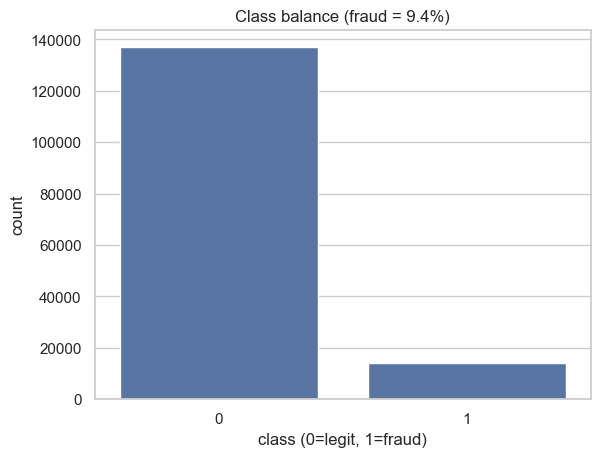

In [7]:
from src.resampling import class_distribution
dist = class_distribution(df['class'])
display(dist)
fraud_rate = df['class'].mean()
print(f'Fraud rate: {fraud_rate:.2%}')

ax = sns.countplot(x='class', data=df)
ax.set(title=f'Class balance (fraud = {fraud_rate:.1%})',
       xlabel='class (0=legit, 1=fraud)', ylabel='count')
plt.savefig(FIG / 'fraud_class_balance.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Univariate distributions

Key numeric and categorical variables.

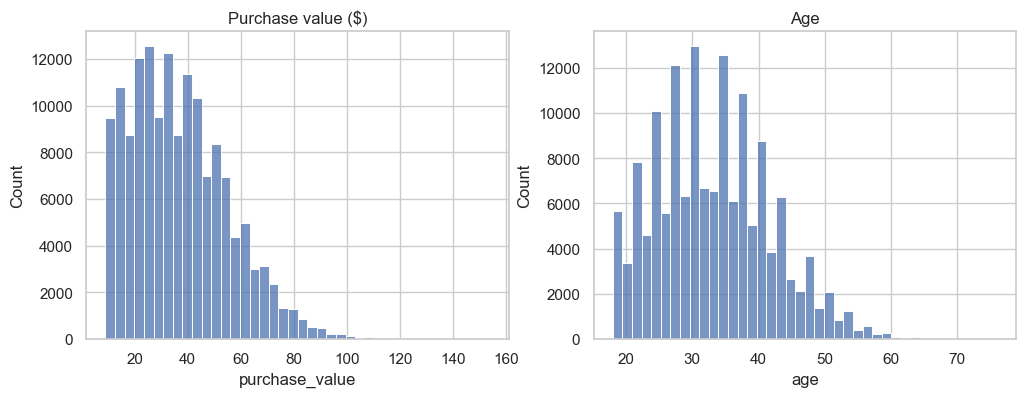

,purchase_value,age
count,151112.000000,151112.000000
mean,36.935372,33.140704
std,18.322762,8.617733
min,9.000000,18.000000
25%,22.000000,27.000000
50%,35.000000,33.000000
75%,49.000000,39.000000
max,154.000000,76.000000


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['purchase_value'], bins=40, ax=axes[0])
axes[0].set_title('Purchase value ($)')
sns.histplot(df['age'], bins=40, ax=axes[1])
axes[1].set_title('Age')
plt.savefig(FIG / 'fraud_univariate_numeric.png', dpi=120, bbox_inches='tight')
plt.show()
df[['purchase_value', 'age']].describe()

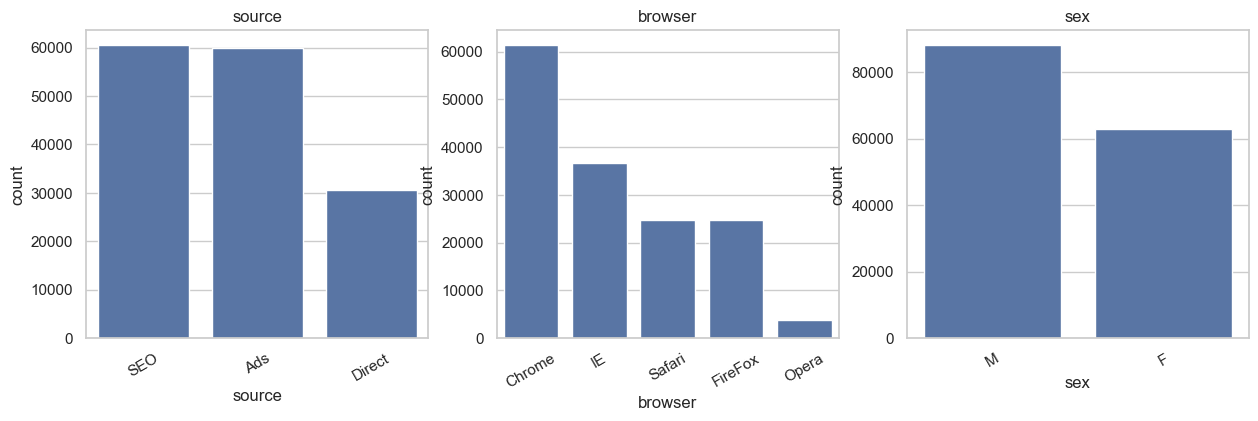

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['source', 'browser', 'sex']):
    order = df[col].value_counts().index
    sns.countplot(x=col, data=df, order=order, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.savefig(FIG / 'fraud_univariate_categorical.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Bivariate relationships with the target

How does each feature differ between fraudulent and legitimate transactions?

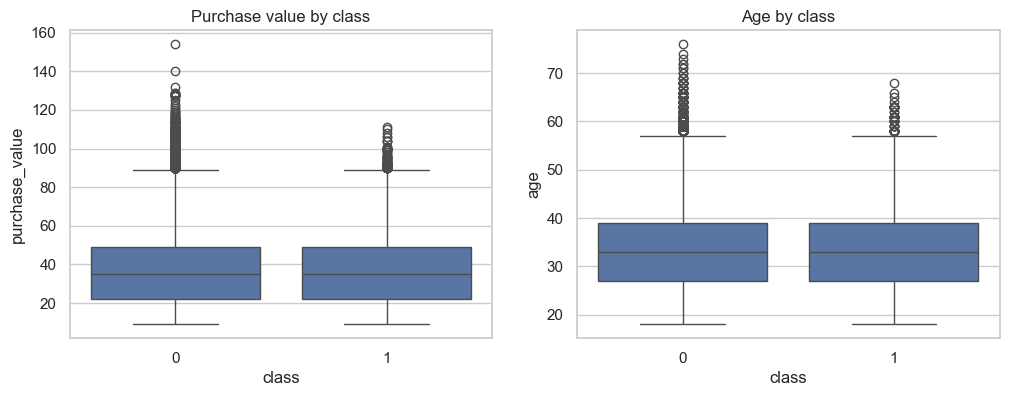

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='class', y='purchase_value', data=df, ax=axes[0])
axes[0].set_title('Purchase value by class')
sns.boxplot(x='class', y='age', data=df, ax=axes[1])
axes[1].set_title('Age by class')
plt.savefig(FIG / 'fraud_bivariate_numeric.png', dpi=120, bbox_inches='tight')
plt.show()

In [11]:
# Fraud rate by categorical level — the actionable view.
for col in ['source', 'browser', 'sex']:
    rate = df.groupby(col, observed=True)['class'].mean().sort_values(ascending=False)
    print(f'\nFraud rate by {col}:')
    print((rate * 100).round(2).astype(str) + '%')


Fraud rate by source:
source
Direct    10.54%
Ads        9.21%
SEO        8.93%
Name: class, dtype: str

Fraud rate by browser:
browser
Chrome     9.88%
FireFox    9.52%
Safari     9.02%
Opera      8.92%
IE         8.68%
Name: class, dtype: str

Fraud rate by sex:
sex
M    9.55%
F     9.1%
Name: class, dtype: str


## 6. Key findings

- **Imbalance:** ~9.4% of transactions are fraudulent — a minority class large enough for SMOTE but small enough that accuracy is a useless metric (a trivial all-legit classifier scores ~90.6%). We will evaluate with **AUC-PR, recall, precision and F1**.
- **Purchase value / age** distributions overlap substantially between classes — no single numeric feature cleanly separates fraud, motivating the engineered time/velocity features in `feature-engineering.ipynb`.
- **Channel/browser** fraud rates vary, providing categorical signal (one-hot encoded downstream).
- **Device sharing** is widespread and retained as a fraud signal.